# Examen Machine Learning I
## Universidad Mayor

**Alumna:** Paulina Godoy

## Metadatos del dataset

- **Nombre del dataset:** California Housing Dataset
- **Fuente:** StatLib
- **URL:** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html
- **Número de filas:** 20640
- **Número de columnas:** 9
- **Variable Objetivo:** MedHouseVal
- **Timpo de tarea**: Regresión

### Importación de librerías y configuración

In [55]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor

In [30]:
# Configuración de estilo para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 12, 'figure.titlesize': 14})

In [31]:
# Creamos la carpeta 'figures/' si no existe
os.makedirs('figures', exist_ok=True)
print("Carpeta 'figures/' verificada/creada exitosamente.")

Carpeta 'figures/' verificada/creada exitosamente.


### Carga de datos y revisión inicial

In [32]:
# Cargamos el dataset de California Housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [33]:
# Revisión de dimensiones, tipos de datos y estadísticas descriptivas
print("------ Shape ------")
print(df.shape)
print("------ Tipos de datos por columna (dtypes) ------")
print(df.dtypes)
print("------ Info ------")
df.info()
print("------ Estadísticas descriptivas iniciales ------")
df.describe()

------ Shape ------
(20640, 9)
------ Tipos de datos por columna (dtypes) ------
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object
------ Info ------
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
------ Estadísticas descriptivas iniciales ------


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [34]:
print("----- 5 primeras filas -----")
df.head()

----- 5 primeras filas -----


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Análisis y tratamiento de valores nulos

Porcentaje de valores nulos por columna:
MedInc         0.0
HouseAge       0.0
AveRooms       0.0
AveBedrms      0.0
Population     0.0
AveOccup       0.0
Latitude       0.0
Longitude      0.0
MedHouseVal    0.0
dtype: float64


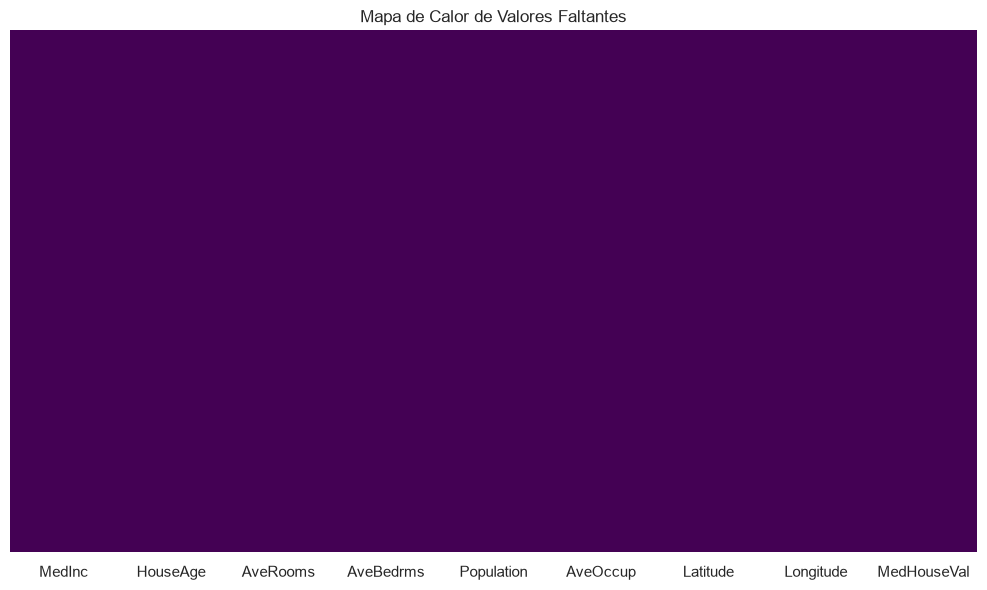

In [35]:
# Porcentaje de nulos por columna
null_percentages = df.isnull().mean() * 100
print("Porcentaje de valores nulos por columna:")
print(null_percentages.round(4))

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Faltantes')
plt.tight_layout()
plt.savefig('figures/01_missing_values_heatmap.png', dpi=150)
plt.show()

**Justificación de tratamiento de valores nulos:** Ya que el dataset no contiene valores nulos en ninguna de las columnas, no se requiere imputación ni eliminación de columnas. Sin embargo, para seguir buenas prácticas de robustez del pipeline, se incluirá un SimpleImputer(strategy='median') dentro del ColumnTransformer. De esta forma, el flujo de procesamiento será reproducible con nuevaos datos que sí pudieran contener nulos.

### Detección y tratamiento de outliers

**Nota:** En la primera iteración de esta sección se detectó que la variables clave tienen escalas muy distintas entre si, por lo que se tomó la decisión de graficar los boxplots en paneles individuales, ya que graficarlos juntos hace ilegibles a las variables de menor magnitud.

Adicionalmente, es relevante notar que el filtrado por IQR se aplica de forma simultánea. Es decir, los límites (Q1, Q3) de cada variable se calculan siempre sobre el dataset original completo, y luego se combinan todas las condiciones en una única máscara booleana. Así se evita que el orden de las cariables en key_variables afecte el resultado final.

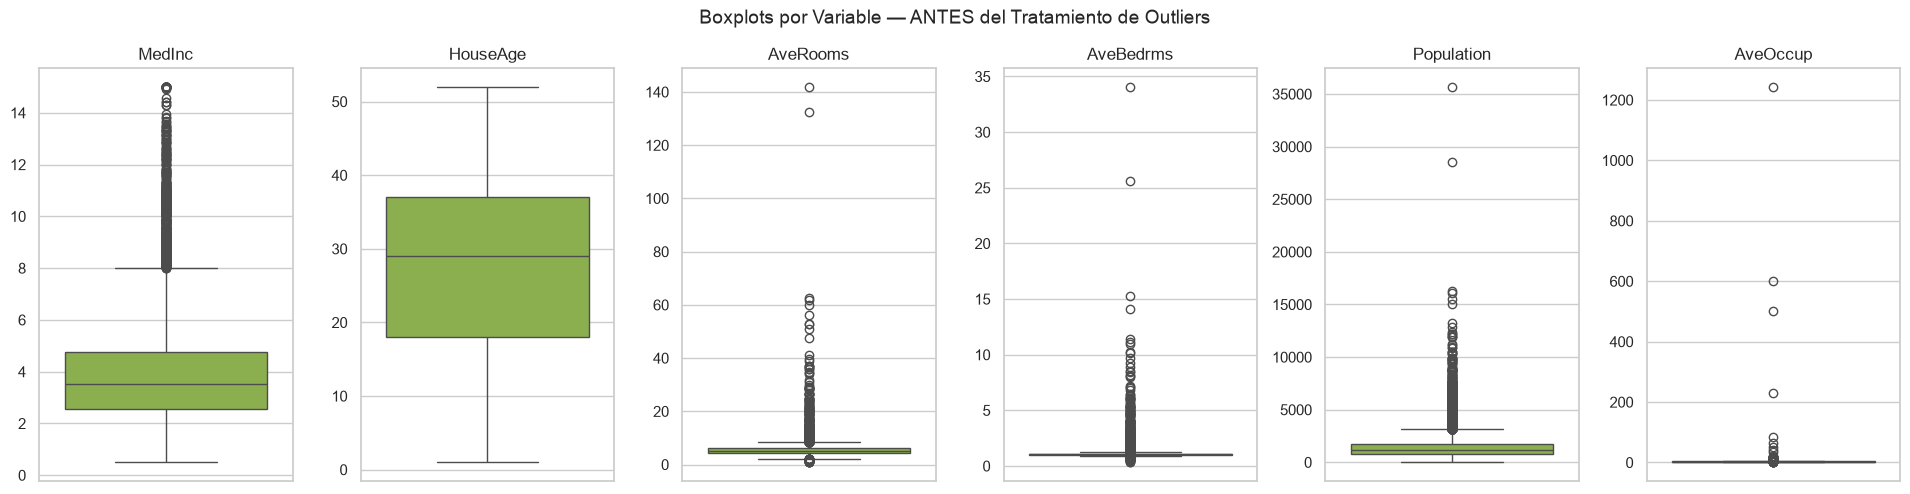

In [36]:
key_variables = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']

def plot_boxplots_por_variable(data, variables, filename, titulo):
    fig, axes = plt.subplots(1, len(variables), figsize=(3.2*len(variables), 5))
    for ax, var in zip(axes, variables):
        sns.boxplot(y=data[var], ax=ax, color='#8FBF3F')
        ax.set_title(var)
        ax.set_ylabel('')
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

plot_boxplots_por_variable(df, key_variables, 'figures/02_boxplots_antes_outliers.png',
                            'Boxplots por Variable — ANTES del Tratamiento de Outliers')


In [37]:
# Diagnóstico de outliers por variable (sobre el dataset ORIGINAL, sin cascada)
print(f"Filas antes de remover outliers: {len(df)}\n")

limites_iqr = {}
mask = pd.Series(True, index=df.index)

for col in key_variables:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    limites_iqr[col] = (lower_limit, upper_limit)

    n_out = ((df[col] < lower_limit) | (df[col] > upper_limit)).sum()
    print(f"{col:12s}: {n_out:5d} outliers ({n_out/len(df)*100:5.2f}%) | límites=[{lower_limit:9.2f}, {upper_limit:9.2f}]")

    mask &= df[col].between(lower_limit, upper_limit)

df_clean = df[mask].copy()

print(f"\nFilas después de remover outliers por método IQR: {len(df_clean)}")
print(f"Observaciones eliminadas: {len(df) - len(df_clean)} ({((len(df) - len(df_clean))/len(df)*100):.2f}%)")


Filas antes de remover outliers: 20640

MedInc      :   681 outliers ( 3.30%) | límites=[    -0.71,      8.01]
HouseAge    :     0 outliers ( 0.00%) | límites=[   -10.50,     65.50]
AveRooms    :   511 outliers ( 2.48%) | límites=[     2.02,      8.47]
AveBedrms   :  1424 outliers ( 6.90%) | límites=[     0.87,      1.24]
Population  :  1196 outliers ( 5.79%) | límites=[  -620.00,   3132.00]
AveOccup    :   711 outliers ( 3.44%) | límites=[     1.15,      4.56]

Filas después de remover outliers por método IQR: 16842
Observaciones eliminadas: 3798 (18.40%)


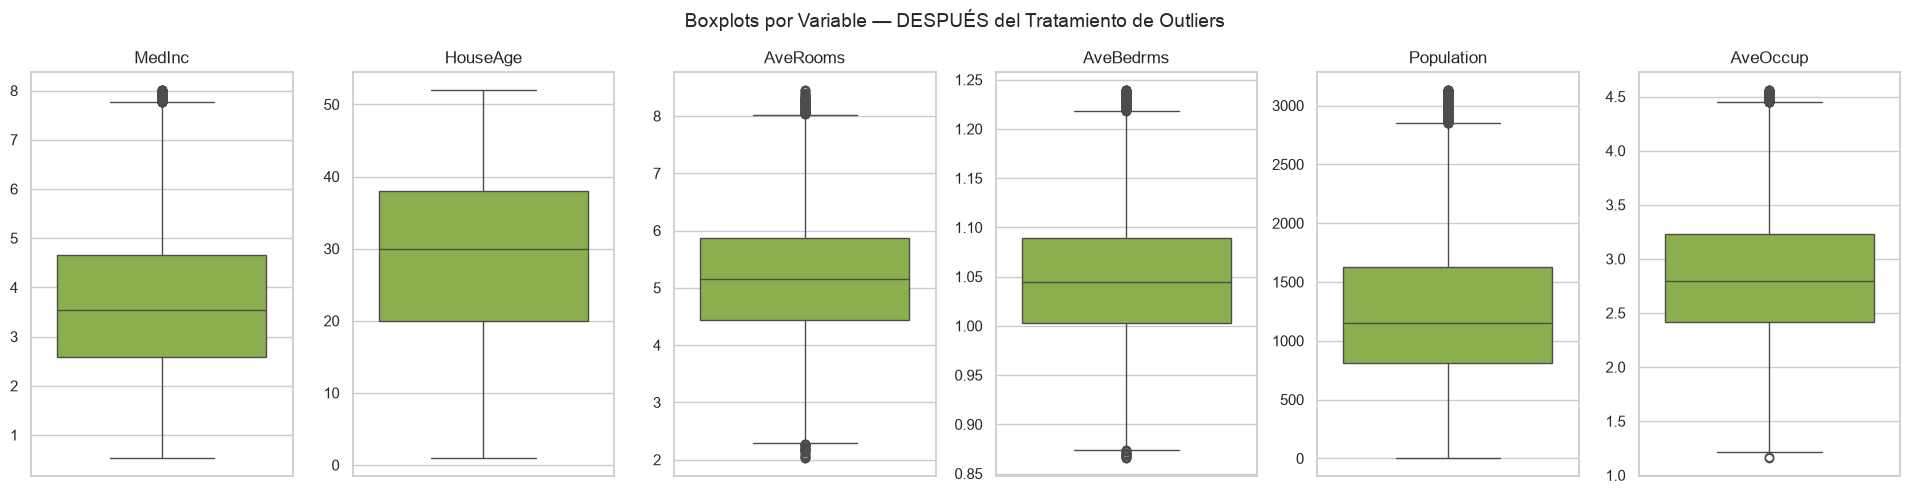

In [38]:
plot_boxplots_por_variable(df_clean, key_variables, 'figures/03_boxplots_despues_outliers.png',
                            'Boxplots por Variable — DESPUÉS del Tratamiento de Outliers')


**Conclusiones EDA:** 

Podemos observar que la única variable sin outliers es HouseAge, por lo que su rango antes y después del filtro aplicado permanece sin cambios. Por otro lado, las variables AveBedrms, Population y AveOccup presentaron la mayor proporción de outliers. 

También llama la atención que la suma de outliers indiviuales (4523) es nayor que el total combinado (3798). Esto indica que muchas filas son outliers en más de una variable, y se produce solapamiento.

Si revisamos los boxplots después del filtro, siguen apareciiendo puntos fuera de los bigotes. Esto es esperable, ya que el boxplot recalcula los cuartiles sobre los datos ya filtrados. Por esta razón, siempre existirá un pequeño porcentaje en los extremos de la nueva distribución.


### Distribución de la variable objetivo

Asimetría (Skewness) de la variable objetivo: 0.9265


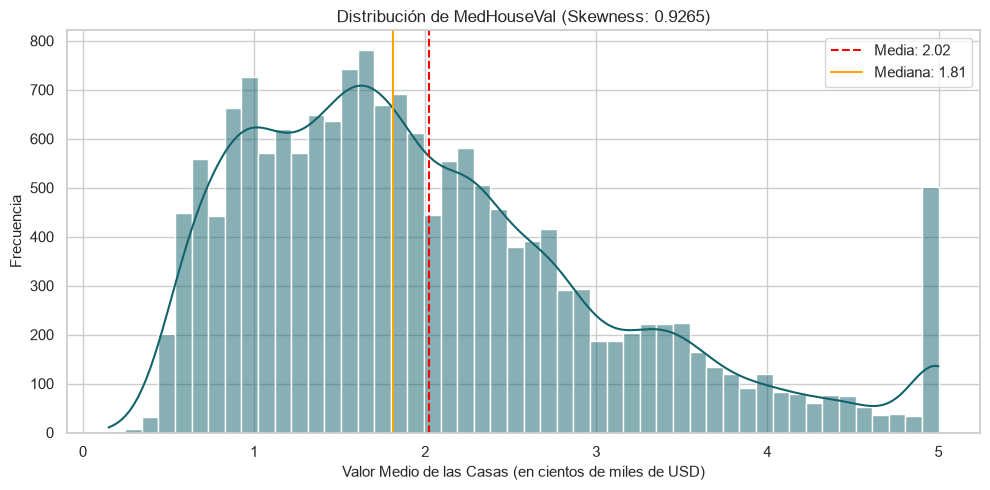

In [51]:
skew_val = df_clean['MedHouseVal'].skew()
print(f"Asimetría (Skewness) de la variable objetivo: {skew_val:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_clean['MedHouseVal'], kde=True, color='#12636B', bins=50, ax=ax)
ax.axvline(df_clean['MedHouseVal'].mean(), color='red', linestyle='--', label=f"Media: {df_clean['MedHouseVal'].mean():.2f}")
ax.axvline(df_clean['MedHouseVal'].median(), color='orange', linestyle='-', label=f"Mediana: {df_clean['MedHouseVal'].median():.2f}")
ax.set_title(f'Distribución de MedHouseVal (Skewness: {skew_val:.4f})')
ax.set_xlabel('Valor Medio de las Casas (en cientos de miles de USD)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('figures/04_target_distribution.png', dpi=150)
plt.show()

In [52]:
# Evaluación condicional de transformación logarítmica (exigido por Punto 7)
usar_log_target = skew_val > 1.0
print(f"¿Skewness > 1.0? {usar_log_target}")

if usar_log_target:
    df_clean['target_log'] = np.log1p(df_clean['MedHouseVal'])  # log1p para manejar posibles ceros
    skew_log = df_clean['target_log'].skew()
    print(f"Skewness original: {skew_val:.4f} -> Skewness tras log1p: {skew_log:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(df_clean['MedHouseVal'], kde=True, ax=axes[0], color='#12636B', bins=50)
    axes[0].set_title(f'Target original (skew={skew_val:.3f})')
    sns.histplot(df_clean['target_log'], kde=True, ax=axes[1], color='darkorange', bins=50)
    axes[1].set_title(f'Target transformado log1p (skew={skew_log:.3f})')
    plt.tight_layout()
    plt.savefig('figures/04b_target_log_transform.png', dpi=150)
    plt.show()
else:
    print("No se aplica transformación logarítmica: la asimetría no supera el umbral de 1.0 definido en la ficha.")


¿Skewness > 1.0? False
No se aplica transformación logarítmica: la asimetría no supera el umbral de 1.0 definido en la ficha.


**Distribución de la variable objetivo:** Se observa un skewness de 0.9265 de la variable objetivo MedHouseVal, lo que inica una asimetría positiva moderada. Debido a que la ficha del examen establace que sólo se debe aplicar una transformación logarítmica cuando el skewness supera el valor 1.0, no corresponde aplicar dicha transformación y el modelo se realiza sobre su escala original. 

En el gráfico podemos observar una acumulación anómala de observaciones en el valor 5.0, límite superior de la variable. Esto se debe a una censura de datos propia del dataset (los valores de vivienda iguales o superiores a 500000 USD fueron truncados a ese techo durante la recolección original).

### Visualizaciones exploratorias

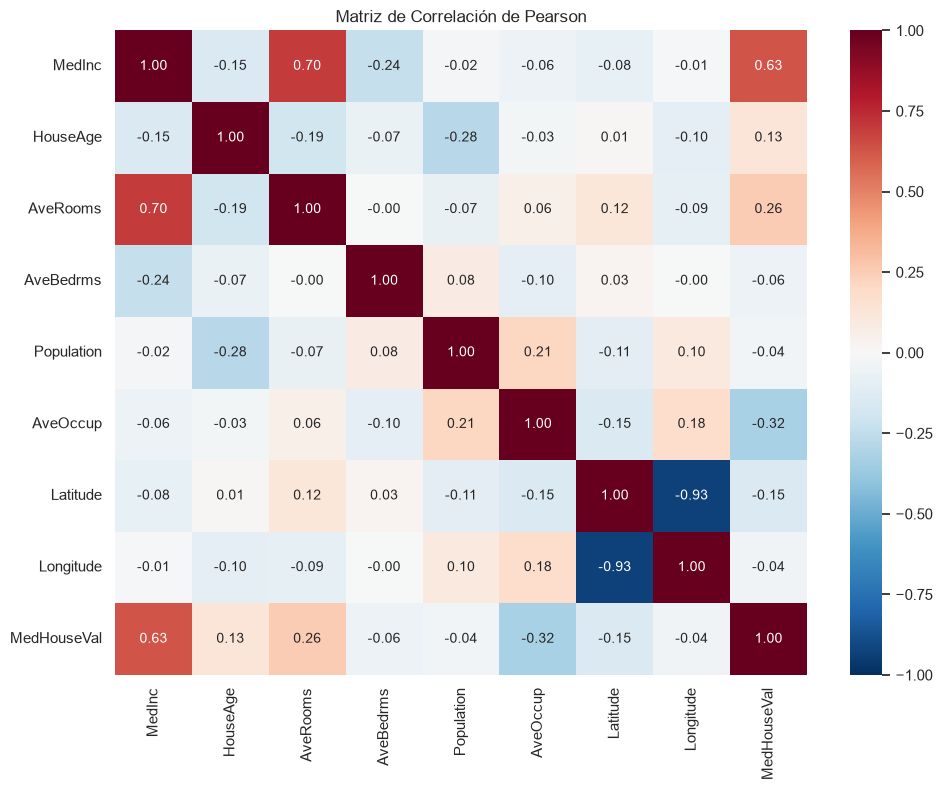

In [41]:
# Heatmap de correlación de Pearson
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean.drop(columns=[c for c in ['target_log'] if c in df_clean.columns]).corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Pearson')
plt.tight_layout()
plt.savefig('figures/05_correlation_heatmap.png', dpi=150)
plt.show()

Las dos variables más correlacionadas con el target son:
  - MedInc: r = 0.6295
  - AveOccup: r = -0.3228


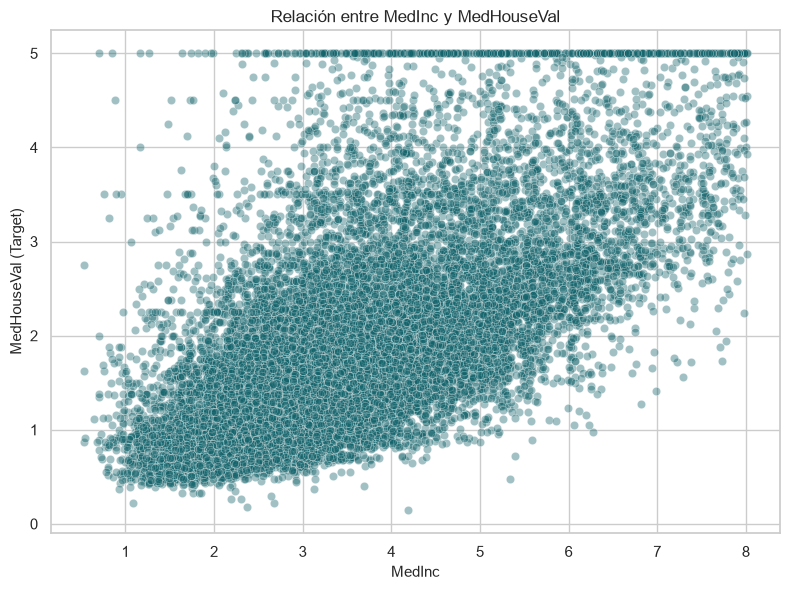

In [43]:
# Scatter plot entre las 2 variables más correlacionadas con el target
corrs_with_target = correlation_matrix['MedHouseVal'].abs().sort_values(ascending=False)
top_predictors = corrs_with_target.index[1:3]  # excluye target mismo
print("Las dos variables más correlacionadas con el target son:")
for pred in top_predictors:
    print(f"  - {pred}: r = {correlation_matrix.loc['MedHouseVal', pred]:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x=top_predictors[0], y='MedHouseVal', alpha=0.4, color='#12636B')
plt.title(f'Relación entre {top_predictors[0]} y MedHouseVal')
plt.xlabel(top_predictors[0])
plt.ylabel('MedHouseVal (Target)')
plt.tight_layout()
plt.savefig('figures/06_scatter_top_correlated.png', dpi=150)
plt.show()

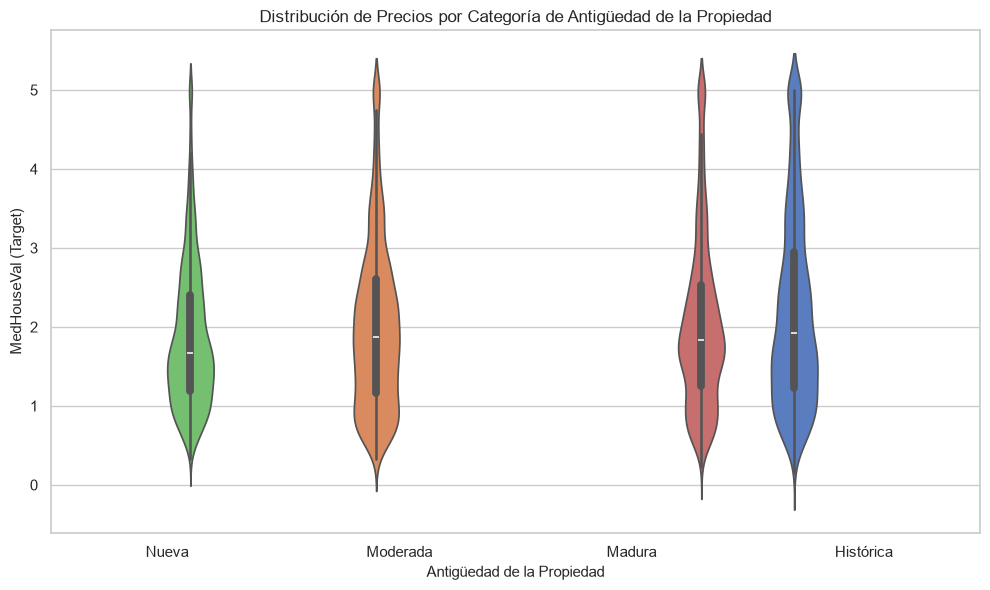

In [57]:
# Violin plot adicional: distribución del target por categoría de antigüedad de la vivienda
df_clean['HouseAge_Bin'] = pd.qcut(df_clean['HouseAge'], q=4, labels=['Nueva', 'Moderada', 'Madura', 'Histórica'])

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_clean, x='HouseAge_Bin', y='MedHouseVal', hue='HouseAge_Bin', palette='muted', legend=False)
plt.title('Distribución de Precios por Categoría de Antigüedad de la Propiedad')
plt.xlabel('Antigüedad de la Propiedad')
plt.ylabel('MedHouseVal (Target)')
plt.tight_layout()
plt.savefig('figures/07_violin_plot.png', dpi=150)
plt.show()

df_clean = df_clean.drop(columns=['HouseAge_Bin'])  # columna auxiliar, no se usa en el modelado

### Multicoliealidad entre predictores

In [58]:
# Top 5 variables más correlacionadas con el target + multicolinealidad entre predictores
print("Top 5 variables más correlacionadas con el target (valor absoluto):")
top_5_corr = corrs_with_target.iloc[1:6]
print(top_5_corr.round(4))

print("\nEvaluando multicolinealidad entre predictores (|r| > 0.85):")
predictor_corr = correlation_matrix.drop(index='MedHouseVal', columns='MedHouseVal')
high_corr_pairs = []
for i in range(len(predictor_corr.columns)):
    for j in range(i):
        val = predictor_corr.iloc[i, j]
        if abs(val) > 0.85:
            high_corr_pairs.append((predictor_corr.columns[i], predictor_corr.columns[j], val))

if not high_corr_pairs:
    print("No se detectó multicolinealidad crítica (|r| > 0.85) entre las variables predictoras.")
else:
    print("Variables predictoras con multicolinealidad (|r| > 0.85):")
    for a, b, v in high_corr_pairs:
        print(f"  - {a} y {b}: r = {v:.4f}")

Top 5 variables más correlacionadas con el target (valor absoluto):
MedInc      0.6295
AveOccup    0.3228
AveRooms    0.2555
Latitude    0.1471
HouseAge    0.1267
Name: MedHouseVal, dtype: float64

Evaluando multicolinealidad entre predictores (|r| > 0.85):
Variables predictoras con multicolinealidad (|r| > 0.85):
  - Longitude y Latitude: r = -0.9336


**Variables más correlacionadas con MedHouseVal:** La variable MedInc (ingreso medio del distrito) es el predictor inividual más fuerte del valor de la vivienda. A esta variable la siguen AveOccup, AveRooms, Latitude y HouseAge, para conformar las 5 variables más correlacionadas con el target.  

**Multicolinealidad:** Se identificó un único par que supera el umbral crítico (|r|>0.85), Longitude y Latitude, con r=-0.9336. 

### Divisón de datos en train/test

In [59]:
X = df_clean.drop(columns=[c for c in ['MedHouseVal', 'MedHouseVal_log'] if c in df_clean.columns])
y = df_clean['MedHouseVal_log'] if usar_log_target else df_clean['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")

Dimensiones de X_train: (13473, 8)
Dimensiones de X_test:  (3369, 8)


### ColumnTransformer (pipeline de preprocesamiento)

In [60]:
numeric_features = X.columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features)
])

# Ajustar SOLO con X_train para evitar data leakage
X_train_prep = preprocessor.fit_transform(X_train)
# Aplicar únicamente transform sobre X_test
X_test_prep = preprocessor.transform(X_test)

print("Pipeline ColumnTransformer (Imputer + StandardScaler) ejecutado sin data leakage.")
print(f"X_train_prep shape: {X_train_prep.shape} | X_test_prep shape: {X_test_prep.shape}")


Pipeline ColumnTransformer (Imputer + StandardScaler) ejecutado sin data leakage.
X_train_prep shape: (13473, 8) | X_test_prep shape: (3369, 8)


### PCA sobre x_train

In [61]:
pca = PCA(n_components=None, random_state=42)
X_train_pca = pca.fit_transform(X_train_prep)

pve = pca.explained_variance_ratio_
cpve = pve.cumsum()

pca_table = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(pve))],
    'Varianza Explicada (PVE)': pve,
    'Varianza Acumulada (CPVE)': cpve
})
pca_table.round(4)

,Componente,Varianza Explicada (PVE),Varianza Acumulada (CPVE)
0,PC1,0.2572,0.2572
1,PC2,0.2241,0.4813
2,PC3,0.1629,0.6442
3,PC4,0.1329,0.7771
4,PC5,0.1058,0.8829
5,PC6,0.0822,0.9651
6,PC7,0.0294,0.9945
7,PC8,0.0055,1.0000


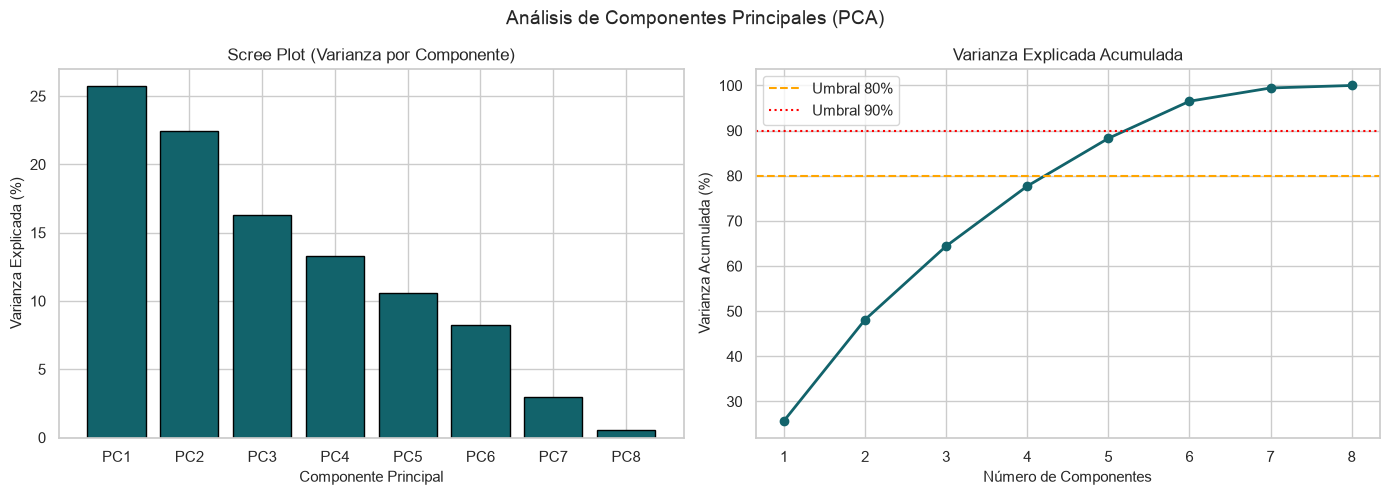

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar([f'PC{i+1}' for i in range(len(pve))], pve*100, color='#12636B', edgecolor='black')
ax1.set_title('Scree Plot (Varianza por Componente)')
ax1.set_ylabel('Varianza Explicada (%)')
ax1.set_xlabel('Componente Principal')

ax2.plot(range(1, len(cpve)+1), cpve*100, marker='o', color='#12636B', linewidth=2)
ax2.axhline(y=80, color='orange', linestyle='--', label='Umbral 80%')
ax2.axhline(y=90, color='red', linestyle=':', label='Umbral 90%')
ax2.set_title('Varianza Explicada Acumulada')
ax2.set_ylabel('Varianza Acumulada (%)')
ax2.set_xlabel('Número de Componentes')
ax2.legend()

plt.suptitle('Análisis de Componentes Principales (PCA)')
plt.tight_layout()
plt.savefig('figures/08_pca_explained_variance.png', dpi=150)
plt.show()


### Selección de n_components

In [63]:
# Selección de n_components entre 80% y 90% de varianza acumulada
candidatos = np.where((cpve >= 0.80) & (cpve <= 0.90))[0]
if len(candidatos) > 0:
    n_comp_opt = candidatos[0] + 1
else:
    # Si ningún componente cae exactamente en el rango, se toma el primero que supere el 80%
    n_comp_opt = np.argmax(cpve >= 0.80) + 1

print(f"Número óptimo de componentes seleccionado: {n_comp_opt} (explica el {cpve[n_comp_opt-1]*100:.2f}% de la varianza)")

pca_opt = PCA(n_components=n_comp_opt, random_state=42)
X_train_pca_opt = pca_opt.fit_transform(X_train_prep)
X_test_pca_opt = pca_opt.transform(X_test_prep)

Número óptimo de componentes seleccionado: 5 (explica el 88.29% de la varianza)


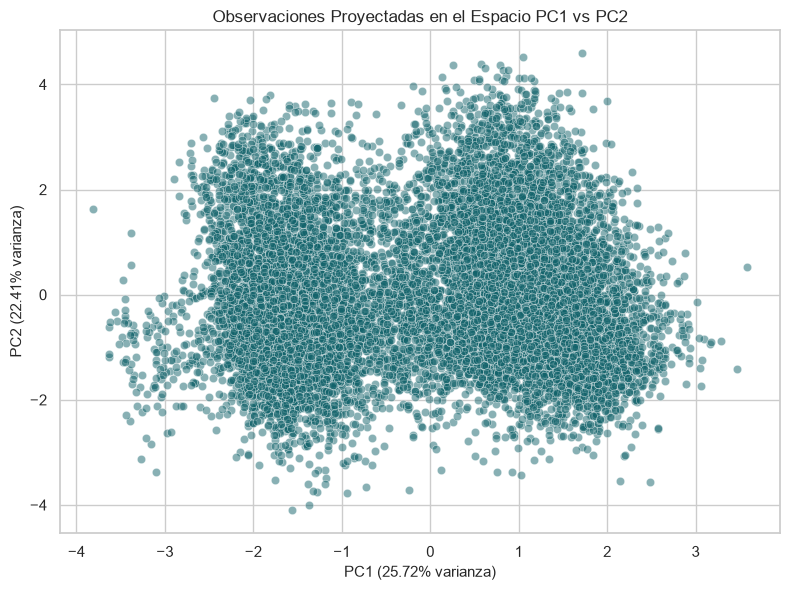

In [64]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], alpha=0.5, color='#12636B')
plt.title('Observaciones Proyectadas en el Espacio PC1 vs PC2')
plt.xlabel(f'PC1 ({pve[0]*100:.2f}% varianza)')
plt.ylabel(f'PC2 ({pve[1]*100:.2f}% varianza)')
plt.tight_layout()
plt.savefig('figures/09_pca_space_2d.png', dpi=150)
plt.show()

In [65]:
loadings = pd.DataFrame(
    pca_opt.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=numeric_features
)
print("Contribución de las variables originales (loadings) en PC1 y PC2:")
print(loadings.round(4))

print("\nTop 5 variables con mayor contribución (valor absoluto) en PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))
print("\nTop 5 variables con mayor contribución (valor absoluto) en PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

Contribución de las variables originales (loadings) en PC1 y PC2:
               PC1     PC2
MedInc     -0.1046  0.6689
HouseAge   -0.0703 -0.2865
AveRooms   -0.1946  0.6300
AveBedrms   0.0110 -0.1971
Population  0.2078  0.0513
AveOccup    0.2359  0.0881
Latitude   -0.6470 -0.1164
Longitude   0.6547  0.1036

Top 5 variables con mayor contribución (valor absoluto) en PC1:
Longitude     0.654713
Latitude      0.647021
AveOccup      0.235909
Population    0.207831
AveRooms      0.194578
Name: PC1, dtype: float64

Top 5 variables con mayor contribución (valor absoluto) en PC2:
MedInc       0.668950
AveRooms     0.629994
HouseAge     0.286539
AveBedrms    0.197064
Latitude     0.116362
Name: PC2, dtype: float64


**Justificación selección de n_components:** Se seleccionaron 5 componentes principales, que explican el 88.29% de la varianza total del dataset. Esto representa una reducción de dimensionalidad de 8 a 5 variables (37.5% menos).

**PC1 (25.72% de la varianza):** Está dominado por Logitude y Latitude, con signos opuestos y magintudes casi ideanticas (0.65 y -0.65 respectivamente). Esto confirma lo anticipado, PC1 es un eje geográfico que resume la posición este-oeste/norte-sur del estado de California. De esta forma condensamos en una sola componente la información que estas dos variables compartían de forma redundante (r=-0.9336). Las variables AveOccup, Population y AveRooms contribuyen con pesos moderados adicionales.

**PC2 (22.41% de la varianza):** Está dominado por MedInc (0.67) y AveRooms (0.63), lo que tiene coherencia con la correlación del 0.70 que encontramos entre estas dos variables en la matriz de Pearson. Este funciona como un eje socioeconómico/estructural, que combina ingreso del distrito con tamaño promedio de las viviendas.

### K-Means

In [66]:
inertias = []
sil_scores = []
k_range = range(2, 11)

# Silhouette es O(n^2): se calcula sobre una muestra representativa para eficiencia
np.random.seed(42)
sample_size = min(3000, X_train_pca_opt.shape[0])
sample_indices = np.random.choice(X_train_pca_opt.shape[0], size=sample_size, replace=False)
X_sample = X_train_pca_opt[sample_indices]

for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels_k = km.fit_predict(X_train_pca_opt)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels_k[sample_indices]))
    print(f"K={k}: Inercia={km.inertia_:.2f} | Silhouette={sil_scores[-1]:.4f}")

K=2: Inercia=71540.05 | Silhouette=0.2471
K=3: Inercia=61190.77 | Silhouette=0.2213
K=4: Inercia=54605.02 | Silhouette=0.2063
K=5: Inercia=48621.46 | Silhouette=0.2039
K=6: Inercia=44799.88 | Silhouette=0.2033
K=7: Inercia=41512.87 | Silhouette=0.2023
K=8: Inercia=39232.78 | Silhouette=0.1997
K=9: Inercia=37055.31 | Silhouette=0.1922
K=10: Inercia=35527.09 | Silhouette=0.1923


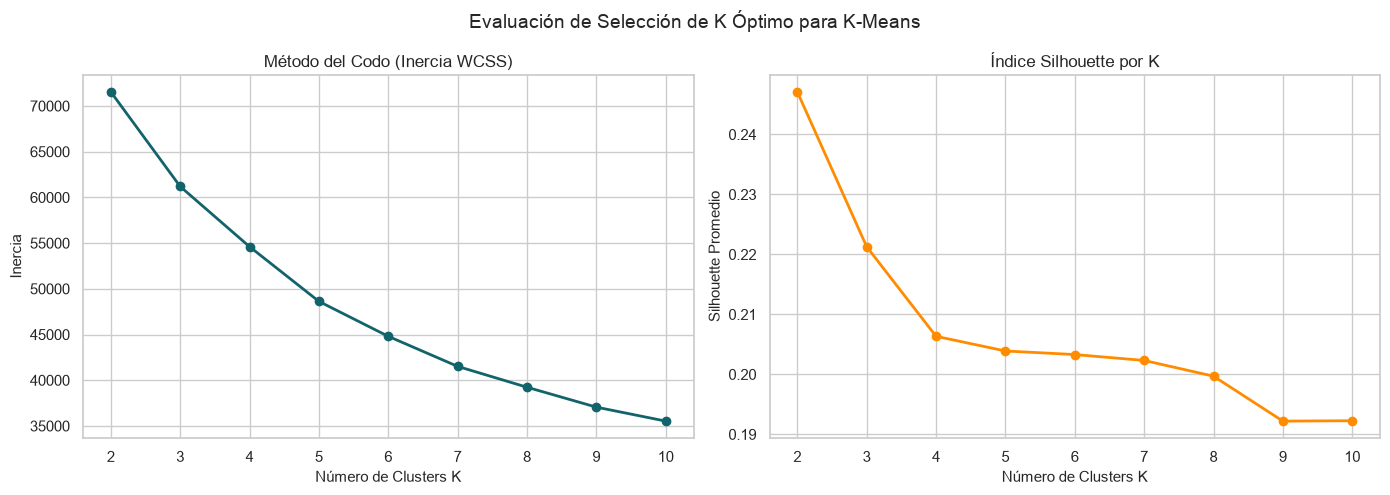

K óptimo seleccionado (máximo Silhouette): K=2


In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, 'o-', color='#12636B', linewidth=2)
ax1.set_title('Método del Codo (Inercia WCSS)')
ax1.set_xlabel('Número de Clusters K')
ax1.set_ylabel('Inercia')

ax2.plot(list(k_range), sil_scores, 'o-', color='darkorange', linewidth=2)
ax2.set_title('Índice Silhouette por K')
ax2.set_xlabel('Número de Clusters K')
ax2.set_ylabel('Silhouette Promedio')

plt.suptitle('Evaluación de Selección de K Óptimo para K-Means')
plt.tight_layout()
plt.savefig('figures/10_kmeans_evaluation.png', dpi=150)
plt.show()

k_opt = list(k_range)[int(np.argmax(sil_scores))]
print(f"K óptimo seleccionado (máximo Silhouette): K={k_opt}")

**K óptimo:** Tanto el método del codo como el ínice Silhouette convergen en K=2 como número óptimo de clusters.

### Clustering con K óptimo

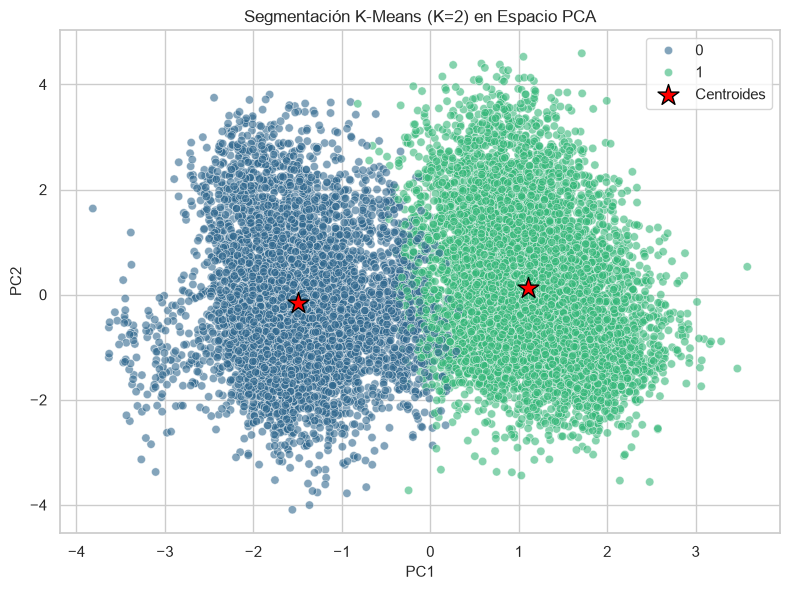

In [68]:
kmeans_opt = KMeans(n_clusters=k_opt, n_init=25, random_state=42)
train_cluster_labels = kmeans_opt.fit_predict(X_train_pca_opt)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train_pca_opt[:, 0], y=X_train_pca_opt[:, 1],
                hue=train_cluster_labels, palette='viridis', alpha=0.6, legend='full')
centroids_pca = kmeans_opt.cluster_centers_
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='*', s=250,
            color='red', edgecolor='black', label='Centroides')
plt.title(f'Segmentación K-Means (K={k_opt}) en Espacio PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig('figures/11_kmeans_clusters_pca.png', dpi=150)
plt.show()

In [69]:
X_train_df = pd.DataFrame(X_train.values, columns=numeric_features, index=X_train.index)
X_train_df['cluster'] = train_cluster_labels
cluster_profiles = X_train_df.groupby('cluster').mean()
cluster_profiles.round(4)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
cluster,,,,,,,,
0,3.7131,29.7347,5.3426,1.0476,1183.5148,2.7197,37.9288,-121.7508
1,3.7218,29.5664,5.0432,1.0476,1319.8206,2.9441,33.9720,-118.0546


**Perfilamiento de clusters:** Se puede observar que la segmentación encontrada por K-Means (K=2) es de naturaleza geográfica. Las variables MedInc, HouseAge y AveBedrds son prácticamente iguales entre ambos clusters, mientras que Latitude y Longitude presentan diferencias importantes. Esto confirma la interpretación de PC1 como un eje geográfico. El algoritmo, sin conocer la unicación real de los distritos, separó naturalmente las dos áreas metropolitanas principales de california representadas en el dataset.

### Entrenamiento de modelo Lasso, regularización L1

In [70]:
# Modelo 1: Regresión Lasso ajustada con GridSearchCV (para poder reportar .best_params_)
print("Entrenando Modelo 1: Regresión Lasso...")
start_time_lasso = time.time()

alphas_grid = [0.001, 0.01, 0.1, 1, 10, 100]
lasso_grid = GridSearchCV(
    estimator=Lasso(random_state=42, max_iter=10000),
    param_grid={'alpha': alphas_grid},
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
lasso_grid.fit(X_train_prep, y_train)
time_lasso = time.time() - start_time_lasso

lasso_model = lasso_grid.best_estimator_
print(f"Lasso entrenado en {time_lasso:.4f} segundos.")
print(f"Mejores hiperparámetros: {lasso_grid.best_params_}")

Entrenando Modelo 1: Regresión Lasso...
Lasso entrenado en 2.3236 segundos.
Mejores hiperparámetros: {'alpha': 0.001}


### Entrenamiento de modelo Random Forest Regressor ajustado con GridSearchCV

In [71]:
# Modelo 2: Random Forest Regressor ajustado con GridSearchCV
print("Entrenando Modelo 2: Random Forest Regressor...")
start_time_rf = time.time()

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_rf.fit(X_train_prep, y_train)
time_rf = time.time() - start_time_rf

best_rf_model = grid_rf.best_estimator_
print(f"Random Forest entrenado en {time_rf:.4f} segundos.")
print(f"Mejores hiperparámetros: {grid_rf.best_params_}")
print(f"Mejor RMSE de validación cruzada: {-grid_rf.best_score_:.4f}")


Entrenando Modelo 2: Random Forest Regressor...
Random Forest entrenado en 40.6088 segundos.
Mejores hiperparámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Mejor RMSE de validación cruzada: 0.4941


### Evaluación de modelos sobre el conjunto de prueba

In [72]:
y_pred_lasso_raw = lasso_model.predict(X_test_prep)
y_pred_rf_raw = best_rf_model.predict(X_test_prep)

# Si se aplicó log1p al target, revertir la transformación antes de calcular métricas
if usar_log_target:
    y_test_eval = np.expm1(y_test)
    y_pred_lasso = np.expm1(y_pred_lasso_raw)
    y_pred_rf = np.expm1(y_pred_rf_raw)
else:
    y_test_eval = y_test
    y_pred_lasso = y_pred_lasso_raw
    y_pred_rf = y_pred_rf_raw

def calcular_metricas(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred)
    }

m_lasso = calcular_metricas(y_test_eval, y_pred_lasso)
m_rf = calcular_metricas(y_test_eval, y_pred_rf)

metrics_comparison = pd.DataFrame({
    'Modelo': ['Lasso (Regularizado)', 'Random Forest (Árboles)'],
    'RMSE': [m_lasso['RMSE'], m_rf['RMSE']],
    'MAE': [m_lasso['MAE'], m_rf['MAE']],
    'R2': [m_lasso['R2'], m_rf['R2']],
    'MAPE': [m_lasso['MAPE'], m_rf['MAPE']],
    'Tiempo Entrenamiento (seg)': [time_lasso, time_rf]
}).sort_values(by='RMSE', ascending=True).reset_index(drop=True)

metrics_comparison.round(4)

,Modelo,RMSE,MAE,R2,MAPE,Tiempo Entrenamiento (seg)
0,Random Forest (Árboles),0.5002,0.3282,0.7807,0.1835,40.6088
1,Lasso (Regularizado),0.6544,0.4867,0.6246,0.2992,2.3236


In [73]:
metrics_comparison.to_csv('model_comparison_metrics.csv', index=False)
print("Archivo 'model_comparison_metrics.csv' exportado exitosamente.")

Archivo 'model_comparison_metrics.csv' exportado exitosamente.


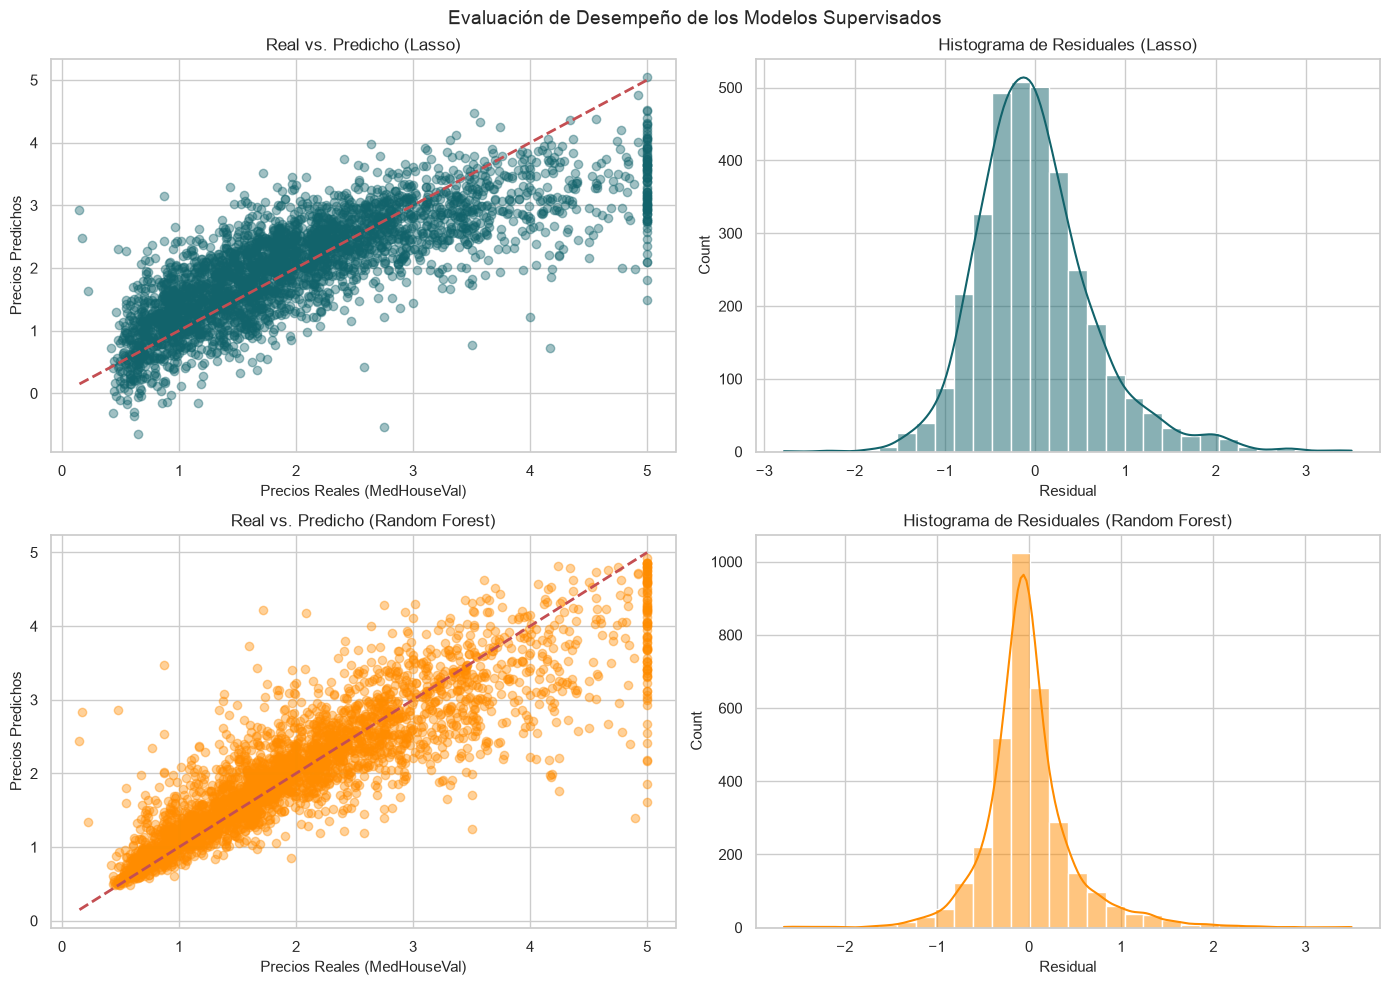

In [74]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

ax1.scatter(y_test_eval, y_pred_lasso, alpha=0.4, color='#12636B')
ax1.plot([y_test_eval.min(), y_test_eval.max()], [y_test_eval.min(), y_test_eval.max()], 'r--', lw=2)
ax1.set_title('Real vs. Predicho (Lasso)')
ax1.set_xlabel('Precios Reales (MedHouseVal)')
ax1.set_ylabel('Precios Predichos')

residuals_lasso = y_test_eval - y_pred_lasso
sns.histplot(residuals_lasso, kde=True, ax=ax2, color='#12636B', bins=30)
ax2.set_title('Histograma de Residuales (Lasso)')
ax2.set_xlabel('Residual')

ax3.scatter(y_test_eval, y_pred_rf, alpha=0.4, color='darkorange')
ax3.plot([y_test_eval.min(), y_test_eval.max()], [y_test_eval.min(), y_test_eval.max()], 'r--', lw=2)
ax3.set_title('Real vs. Predicho (Random Forest)')
ax3.set_xlabel('Precios Reales (MedHouseVal)')
ax3.set_ylabel('Precios Predichos')

residuals_rf = y_test_eval - y_pred_rf
sns.histplot(residuals_rf, kde=True, ax=ax4, color='darkorange', bins=30)
ax4.set_title('Histograma de Residuales (Random Forest)')
ax4.set_xlabel('Residual')

plt.suptitle('Evaluación de Desempeño de los Modelos Supervisados')
plt.tight_layout()
plt.savefig('figures/12_model_performance_evaluation.png', dpi=150)
plt.show()

In [75]:
best_model_name = metrics_comparison.iloc[0]['Modelo']
print(f"Mejor modelo según RMSE de test: {best_model_name}")

if 'Random Forest' in best_model_name:
    best_model_obj = best_rf_model
else:
    best_model_obj = lasso_model

y_train_pred_raw = best_model_obj.predict(X_train_prep)
y_train_eval = np.expm1(y_train) if usar_log_target else y_train
y_train_pred = np.expm1(y_train_pred_raw) if usar_log_target else y_train_pred_raw

rmse_train = np.sqrt(mean_squared_error(y_train_eval, y_train_pred))
rmse_test = metrics_comparison.iloc[0]['RMSE']

print(f"RMSE Train: {rmse_train:.4f}")
print(f"RMSE Test:  {rmse_test:.4f}")
print(f"Diferencia (Test - Train): {rmse_test - rmse_train:.4f}")

Mejor modelo según RMSE de test: Random Forest (Árboles)
RMSE Train: 0.1798
RMSE Test:  0.5002
Diferencia (Test - Train): 0.3204


### Selección del mejor modelo

Se seleccionó el modelo **Random Forest**, pues supera a Lasso en las cuatro métricas de test. La métrica principal considerada fue el RMSE, por penalizar más fuertemente los errores grandes. 

Sin embargo, la comparación train vs. test muestra un sobreajuste significativo. El RMSE en entrenamiento (0.1798) es mucho menor que en test (0.5002). Esto es coherente con la selección del hiperparámetro max_depth: None por GridSearchCV, que permite a los árboles crecer sin restricción de profundida, y por lo tanto, memorizar particularidades del conjunto de entrenamiento. Este es un ejemplo del clásico patrón de alta varianza descrito por el dilema sesgo-varianza. 

Si bien el mecanismo de bagging (promedio de 200 árboles) logra mitigar parcialmente esta varianza, no la elimina por completo. El modelo generaliza peor de lo que su desempeño en entrenamiento nos sugería. Aún así, el modelo Random Forest sigue siendo la mejor opción entre los dos evaluados. Incluso con este sobreajuste, su RMSE de test es considerablemente mejor que el de Lasso. 

En cuanto al trade-off desempeño/interpretabilidad, Lasso ofrece coeficientes directamente interpretables, mientras que Random Forest sacrifica interpretabilidad a cambio de captirar relaciones no lineales entre predictores. Si vemos los tiempos, Random Forest requierió aproximadamente 17 veces más tiempo de entrenamiento con GridSearchCV. Esta diferencia se puede asimilar, al ser una operación única. 

### Importancia de variables del mejor modelo

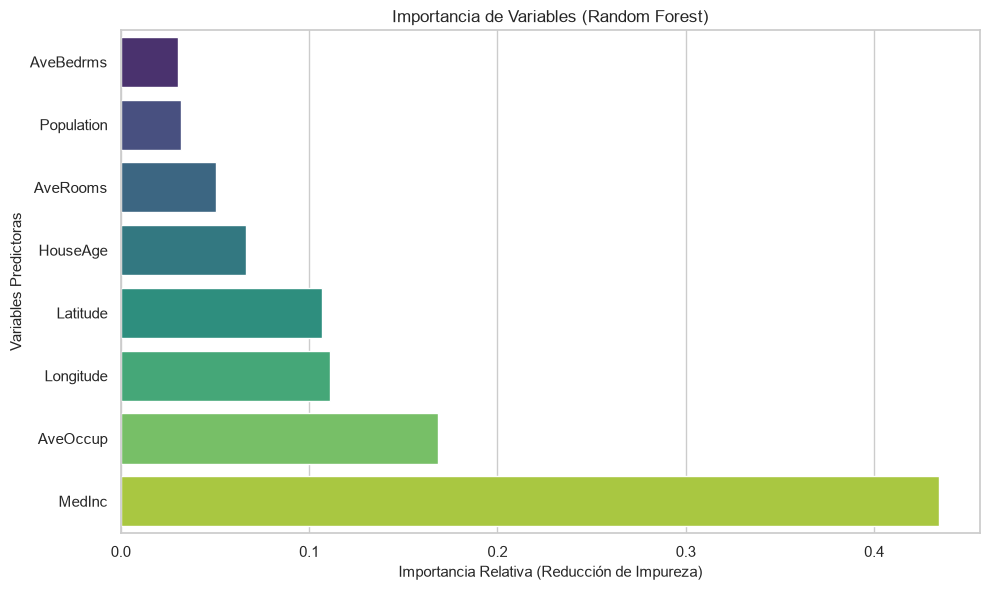

Top 5 variables más influyentes:
MedInc       0.434490
AveOccup     0.168225
Longitude    0.111325
Latitude     0.106841
HouseAge     0.066350
dtype: float64


In [77]:
plt.figure(figsize=(10, 6))

if 'Random Forest' in best_model_name:
    importances = best_rf_model.feature_importances_
    feat_series = pd.Series(importances, index=numeric_features).sort_values(ascending=True)
    sns.barplot(x=feat_series.values, y=feat_series.index, hue=feat_series.index, palette='viridis', legend=False)
    plt.title('Importancia de Variables (Random Forest)')
    plt.xlabel('Importancia Relativa (Reducción de Impureza)')
else:
    coefficients = lasso_model.coef_
    feat_series = pd.Series(coefficients, index=numeric_features).sort_values(key=abs, ascending=True)
    sns.barplot(x=feat_series.values, y=feat_series.index, hue=feat_series.index, palette='RdBu_r', legend=False)
    plt.title('Coeficientes Estandarizados (Regresión Lasso)')
    plt.xlabel('Magnitud del Coeficiente')

plt.ylabel('Variables Predictoras')
plt.tight_layout()
plt.savefig('figures/13_feature_importance.png', dpi=150)
plt.show()

print("Top 5 variables más influyentes:")
print(feat_series.abs().sort_values(ascending=False).head(5))

**Importancia de variables de Random Forrest:** Las 5 variables más importantes son MedInc, AveOccup, Longitude, Latitude y HouseAge. Esto indica, analizando en lenguaje de negocio, que el ingreso medio del distrito es el factor más determinante del valor de vivienda, seguido por el nivel de ocupación por hogar (hacinamiento) y por la ubicación geográfica exacta del distrito.

Si comparamos esto con las correlaciones de Pearson del EDA, MedInc, AveOccup y HouseAge coinciden en su posición relativa en ambos rankings, lo que valida su importancia de forma consistente en un enfoque lineal y uno no lineal. 

Sin embargo, podemos observar una discrepancia importante en las variables Longitude y Latitude. Ambas presentan una correlación de Pearson muy baja con la variable objetivo (-0.04 y -0.15 respectivamente), mientras para Random Forest ocupan el 3° t 4° lugar en importancia. Esto se debe a que Pearson solo caputar relaciones lineales, y el valor de vivienda varía de forma no lineal y no monotónica según la geografía (concentrandose en focos específicos). Este tipo de patrones pueden ser caputados por un árbol de decisión a través de particiones sucesivas del espacio.

Por otro lado, AveRooms muestra una correlación moderada (0.2555) pero baja importancia en el modelo (0.05), posiblemente porque su información se solapa parcialmente con MedInc, lo que reduce su aporte marginal una vez que el árbol ya particiona por ingreso.

### Observaciones con mayor error de predicción

In [78]:
if 'Random Forest' in best_model_name:
    raw_residuals = residuals_rf
else:
    raw_residuals = residuals_lasso

abs_residuals = np.abs(raw_residuals)

test_analysis = X_test.copy()
test_analysis['Real_MedHouseVal'] = y_test_eval.values
test_analysis['Residual_Absoluto'] = abs_residuals.values
test_analysis['Residual'] = raw_residuals.values

top_10_errors = test_analysis.sort_values(by='Residual_Absoluto', ascending=False).head(10)
top_10_errors.round(4)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Real_MedHouseVal,Residual_Absoluto,Residual
489,3.0417,48.0,4.6906,1.1264,1656.0,3.6078,37.86,-122.25,4.896,3.5008,3.5008
10448,1.6393,22.0,4.8198,1.0883,1081.0,1.9099,33.47,-117.67,5.000,3.3940,3.3940
15288,3.5341,15.0,5.6817,1.0594,747.0,1.7743,33.10,-117.31,5.000,3.1467,3.1467
15303,2.3182,24.0,5.5749,1.2044,812.0,2.2125,33.17,-117.36,5.000,2.8250,2.8250
18168,3.5861,16.0,3.2617,1.1438,1479.0,1.4180,37.37,-122.03,5.000,2.8231,2.8231
5887,2.3667,39.0,3.5725,1.2174,259.0,1.8768,34.15,-118.33,0.175,2.6589,-2.6589
8222,5.0000,21.0,3.0625,0.8750,29.0,1.8125,33.76,-118.23,0.875,2.5918,-2.5918
18461,4.6458,17.0,4.9020,1.0196,141.0,2.7647,37.26,-121.76,5.000,2.5828,2.5828
19529,7.3841,40.0,6.6984,1.0000,158.0,2.5079,37.65,-120.98,1.722,2.4953,-2.4953
17477,3.8056,21.0,5.8815,1.1754,746.0,3.5355,34.47,-120.05,4.250,2.4862,2.4862


In [79]:
print("Comparación de las observaciones con mayor error vs. el promedio del conjunto de entrenamiento:")
for col in numeric_features:
    print(f"  {col:12s}: promedio en errores altos = {top_10_errors[col].mean():.4f} | "
          f"promedio global train = {X_train[col].mean():.4f}")

Comparación de las observaciones con mayor error vs. el promedio del conjunto de entrenamiento:
  MedInc      : promedio en errores altos = 3.7322 | promedio global train = 3.7181
  HouseAge    : promedio en errores altos = 26.3000 | promedio global train = 29.6381
  AveRooms    : promedio en errores altos = 4.8146 | promedio global train = 5.1708
  AveBedrms   : promedio en errores altos = 1.0910 | promedio global train = 1.0476
  Population  : promedio en errores altos = 710.8000 | promedio global train = 1261.7493
  AveOccup    : promedio en errores altos = 2.3420 | promedio global train = 2.8485
  Latitude    : promedio en errores altos = 35.2260 | promedio global train = 35.6577
  Longitude   : promedio en errores altos = -119.5970 | promedio global train = -119.6293


**Observaciones con mayor error:** Las 10 observaciones con mayor error absoluto de predicción se pueden explicar por dos mecanismos distintos, y de dirección opuesta. Por un lado, vemos una subestimación en el techo de sensura en 7 de 10 casos. La mayoría de los errores corresponde a viviendas de alto valor real, con 4 de las 10 observaciones ubicadas en el límite de censura de 5.0 identificado anteriormente. Al no observar en entrenamiento valores superiores a este techo, el modelo no puede aprener a extrapolar más allá de él y subestima de manera sistemática estas viviendas.

Por otro lado, encontramos la sobreestimación en distritos atípicos de alto ingreso y baja densidad, en 3 de 10 casos. Este patron nos muestra tres observaciones con precio real muy bajo, pero residual negativo pronunciado. Esto sugiere que se trata de distritos rurales o de muy baja densiadad, donde la relación mayor ingreso, mayor valor de vivienda no se cumple. 

## Conclusiones Ejecutivas

### Hallazos del EDA

El análisis exploratorio del dataset nos reveló una variable objetivo (MedHouseVal) con asimetría positiva moderada, un skewness de 0.9265, levemente por debajo del umbral de 1.0 que nos hubiese lleado a hacer transformación logarítmica. Además, en esta etapa del análisis nos topamos con un hallazgo estructural importante: la variable valor de vivienda está censurado en 5.0 (500 mil dólares), lo que se traduce en una acumulación anómala de observaciones en este valor exacto. 

Ejecutamos el tratamiento de outliers utilizando el método IQR, que eliminó 3798 observaciones (18.40% del total). Las observaciones eliminadas se concetraron principalemente en las variables AveBedrms (6.90%) y Population (5.79%). Esto se debe a que son variables tipo "razón", sensibles a distritos con pocos hogares. Por otro lado la variable HouseAge no presentó outliers, probablemente por ser una variable acotada por diseño.

En cuanto a correlaciones, las variables MedInc y AveOccup mostraron ser los predictores individuales más fuertes de la variable objetivo (r=0.6295 y r=-0.3228 respectivamente). Se detectó además multicolinealidad crítica entre las variables Latitude y Longitude (r=-0.9336), lo que se podría explicar por la orientación geográfica del estado de California. 

### Patrones del análisis no supervisado

El PCA nos permitió reducir de las 8 variables originales del dataset, a 5 componentes principales, reteniendo el 88.29% de la varianza. Los loadings mostraron que el PC1 actúa como un eje geográfico, dominado por las variables Longitude/Latitude, y el PC2 como un eje socioeconómico-estructural, dominado por las variables MedInc/AveRooms, lo que resuelve de forma natural la multicolinealidad geográfica detectada en el EDA. 

El clustering K-Means seleccionó K=2 como óptimo (Silhouette=0.2471, el más alto aunque de magnitud moderada). Al hacer el perfilamiento de clusters, observamos que la segmentación es puramente geográfica, separando distritos del área de la Bahía de San Francisco (Cluster 0) delos del área de Los Ángeles (Cluster 1), con variables como MedInc y AveBedrms prácticamente identicas entre ambos. 

### Modelo seleccionado y justificación

Entrenamos y comparamos dos modelos: Lasso (regularización L1, mejor alpha 0.001) y Random Forest (mejor configuración: 200 árboles, sin límite de profundidad). Seleccionamos el modelo Random Forest por superar a Lasso en las cuatro métricas del test (RMSE 0.5002 vs. 0.6544, MAE 0.3282 vs. 0.4867, R² 0.7807 vs.0.6246 y MAPE 18.35% vs. 29.92%). Sin embargo, se detectó un sobreajuste relevante en Random Forest. El RMSE de entrenamiento (0.1798) es notablemente menor que el de test. Esta diferencia se puede atribuir a la ausencia de límite de profundidad en los árboles.

### Top 3 variables e interpretación de negocio

Las variables más determinantes que encontramos fueron: 
1. MedInc con un 43.45% de importancia: Esto implica que a mayor ingreso medio del distrito, mayor será el valor de la vivienda.
2. AveOccup con un 16.82% de importancia: Esta variable nos indica que los distritos con mayor hacinamiento por hogar tienden a asociarse con menores valores de viviendas.
3. Las variables Longitude y Latitude (11.13 y 10.68% respecticamente) ocupan el tercer y cuarto lugar, a pesar de tener una correlación de Pearson muy baja con la variable objetivo. Esta discrepancia de puede explicar porque la variación en el valor de las viviendas no es lineal según la geografía, sino que se concentran los valores altos en polos específicos como la Bahía de San Francisco y Los Ángeles. Este tipo de patrones son detectados por un modelo de árboles, pero no por un coeficiente de correlación lineal.

### Limitaciones

Las principales limitaciones de nuestro estudio son la siguientes:
1. La variable objetivo es censurada en 5.0. Esto impide que cualquier modelo aprenda a predecir viviendas de mayor valor. El análisis de errores confirmó que 7 de las 10 observaciones con mayor error absoluto correspondían a viviendas de alto valor real, exactamente en este techo.
2. Sobreajuste en Random Forest, observada en una diferencia RMSE train-test de 0.3204. Esto sería producto de utilizar ábroles sin restricción de profundidad.
3. Antiguedad y variables del dataset. Este conjunto de datos contiene información del año 1990, y no incluye algunas variables cualitativas que podrían ser relevantes para explicar variabilidad adicional del precio, como podrían ser calidad de las escuelas, criminalidad o acceso al transporte público. 
4. Distrituso rurales de alto ingreso y baja densidad poblacional. Estos sectores presentan dificultades adicionales para el modelo, pues no cumplen con el patrón general "a mayor ingreso, mayor precio de vivienda".

### Recomendaciones

1. Proponemos acotar explícitamente max_depth en la grilla de búsqueda de Random Forest, en lugar de permitire None, para así evaluar el trade-off entre profundidad limitada y desempeño, reduciendo el sobreajuste detectado.
2. Sería interesante enriquecer el dataset con variables adicionales que ayuden a eplxicar la variabilidad no capturada, especialmente para los distritos atípicos indentificados en el análisis de errores. Algunas variables de interés podrían ser año de construcción, distancia a centros urbanos, y otros indicados de calidad de vida en el barrio.

### Propuesta de trabajo futuro

Se propone explorar un modelo que aproveche de forma explícita la estructura espacial de las variables Latitude/Longitude. Esto podría ser uun clustering geográfico más granular, como insumo para el modelo, o el uso de Gradient Boosting/XGBoost con interacciones espaciales. Nuestro razonamiento aquí, es que el análisis de importancia de variables y el clustering K-MEans coinciden en señalar la geografía como un factor con relaciones no lineales relevante, que los modelos actuales sólo logran captar parcialmente.